# 03 — Modeling

## Logistic Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import plot_tree, export_text, DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
)
import joblib


In [2]:
# load cleaned data
df = pd.read_csv("../data/processed/missing_persons_cleaned.csv")

# datetime
df["dlc"] = pd.to_datetime(df["dlc"], errors="coerce")
df["date_modified"] = pd.to_datetime(df["date_modified"], errors="coerce")

# target: same rule as EDA
df["age_group"] = np.where(df["missing_age"] < 18, "juvenile", "adult")

# exclude leakage / IDs / names from modeling
# (missing_age defines age_group; case_number and legal names are not predictors)
feature_cols = ["biological_sex", "state", "race_ethnicity"]
# optional later: "city", "county", or df["dlc"].dt.year as dlc_year

model_df = df[feature_cols + ["age_group"]].copy()

X = model_df[feature_cols]
y = model_df["age_group"]

print(model_df.shape)
print(y.value_counts())
print(X.isna().sum())
print(X.dtypes)
print(y.dtypes)


(9978, 4)
age_group
adult       7598
juvenile    2380
Name: count, dtype: int64
biological_sex    0
state             0
race_ethnicity    0
dtype: int64
biological_sex    str
state             str
race_ethnicity    str
dtype: object
str


This is the initial data setup, loading the data, setting a target column (age_group), and splitting into X and y.

In [3]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=67,
    stratify=y,
)

Here the train test split is performed using train_test_split from sklearn.model_selection. I used a test size of 20% and set the random_state to 67. This can be copied for exact repetition or changed in order to try a new train, test split.

In [4]:
# pandas string columns may be dtype "str" or "object"
cat_features = X_train.select_dtypes(include=["object", "string", "str"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ]
)
print("Categorical features:", cat_features)


Categorical features: ['biological_sex', 'state', 'race_ethnicity']


Defined categorical features and created the preprocessor using OneHotEncoder on the categorical features.

In [ ]:
# create the logistic regression pipeline
log_reg_pipeline = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('logreg', LogisticRegression(random_state=67, max_iter=5000)),
    ]
)

In [ ]:
# logistic regression parameters for grid search
log_reg_params = {
    'logreg__solver': ['liblinear', 'lbfgs', 'saga'],
    'logreg__C': np.logspace(-5, 5, 100),
}

In [7]:
logreg_cv = GridSearchCV(log_reg_pipeline,
                         param_grid=log_reg_params,
                         cv=5,
                         scoring='accuracy')

logreg_cv.fit(X_train, y_train)

print("Best Params:", logreg_cv.best_params_)
print("Best CV:", logreg_cv.best_score_)
logreg_best = logreg_cv.best_estimator_

Best Params: {'logreg__C': np.float64(0.08697490026177834), 'logreg__solver': 'liblinear'}
Best CV: 0.8008014714306115


Using GridSearchCV, the pipeline, and the parameters, and fitting it on X_train and y_train, I was able to select the best parameters and best CV to use later.

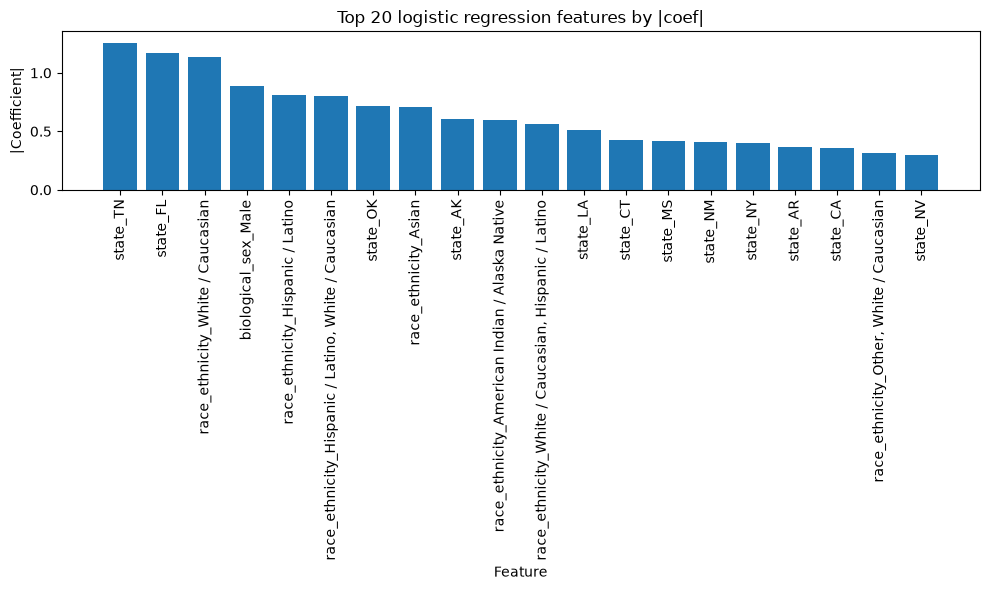

In [8]:
feature_names = (
    logreg_best.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .get_feature_names_out(cat_features)
)

coefs = logreg_best.named_steps["logreg"].coef_.flatten()
abs_coefs = np.abs(coefs)

# top 20 by |coefficient|
top_n = 20
order = np.argsort(abs_coefs)[::-1][:top_n]

top_names = feature_names[order]
top_abs = abs_coefs[order]

plt.figure(figsize=(10, 6))
plt.bar(top_names, top_abs)
plt.xticks(rotation=90)
plt.xlabel("Feature")
plt.ylabel("|Coefficient|")
plt.title(f"Top {top_n} logistic regression features by |coef|")
plt.ylim(0, top_abs.max() + 0.1)
plt.tight_layout()
plt.savefig("../reports/figures/logreg_top_coefs.png", dpi=150, bbox_inches="tight")
plt.show()


This is a list of the top 20 features' logistic weight ranked by absolute value. 

Accuracy:
0.8136272545090181
Confusion Matrix:
[[1465   55]
 [ 317  159]]


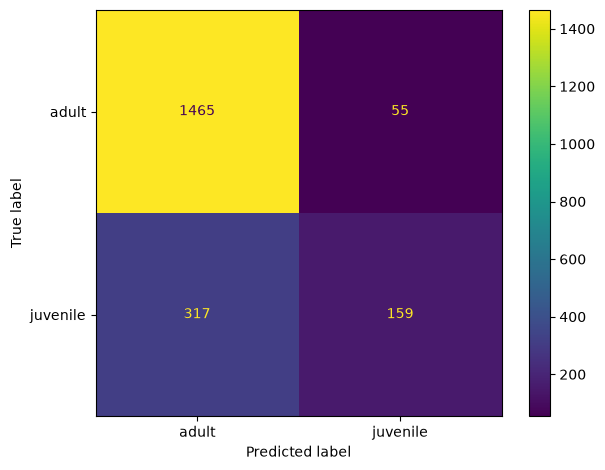

Classification Report:
              precision    recall  f1-score   support

       adult       0.82      0.96      0.89      1520
    juvenile       0.74      0.33      0.46       476

    accuracy                           0.81      1996
   macro avg       0.78      0.65      0.67      1996
weighted avg       0.80      0.81      0.79      1996



In [9]:
y_pred = logreg_best.predict(X_test)

print("Accuracy:")
print(accuracy_score(y_test, y_pred))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)
disp = ConfusionMatrixDisplay(cm, display_labels=logreg_best.classes_)
disp.plot()
plt.tight_layout()
plt.savefig("../reports/figures/logreg_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred))


The classification report and the confusion matrix show generally the same thing. The classification report contains more information, while the confusion matrix puts the most important information into a visual graph for us to see. We can see that this model was phenomenal when it came to adults, a precision of 82% and a recall of 96%. But, this model was not as good at juvenile prediction. 

One idea as to why this may have happened is the pure data amount. This data set contains far more adult cases than juvenile cases. This means that during training, the model has a much higher chance of seeing and training on adult data. 

Another reason that this may have happened would be that this dataset, or at least my analysis of it, may not have been as in-depth and detailed on the features that mattered for juveniles.


## Decision Tree

In [10]:
# Reuse the same X_train / X_test / y_train / y_test from the logistic section
# (same 80/20 split) so the two models are comparable.
print(X_train.shape, X_test.shape)
print(y_train.value_counts())


(7982, 3) (1996, 3)
age_group
adult       6078
juvenile    1904
Name: count, dtype: int64


In [ ]:
# Fresh one-hot preprocessor (same setup as logistic; separate object so fits do not clash).
# Trees do not need StandardScaler; SMOTE is optional and skipped here.
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ]
)

tree_pipeline = Pipeline(
    [
        ("preprocessor", tree_preprocessor),
        (
            "tree",
            DecisionTreeClassifier(
                class_weight="balanced",
                criterion="gini",
                max_depth=3,
                min_samples_leaf=10,
                random_state=67,
            ),
        ),
    ]
)

tree_pipeline.fit(X_train, y_train)


Made the preprocessor like before in the logistic regression model. Made a pipeline for the tree using Pipeline and including DecisionTreeClassifier.


In [12]:
# Optional: small grid over tree depth / leaf size (comment out if you want fixed params only)
tree_params = {
    "tree__max_depth": [2, 3, 4, 5, None],
    "tree__min_samples_leaf": [5, 10, 20],
    "tree__criterion": ["gini", "entropy"],
}

tree_cv = GridSearchCV(
    tree_pipeline,
    param_grid=tree_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)
tree_cv.fit(X_train, y_train)

print("Best Params:", tree_cv.best_params_)
print("Best CV:", tree_cv.best_score_)
tree_best = tree_cv.best_estimator_


Best Params: {'tree__criterion': 'entropy', 'tree__max_depth': 3, 'tree__min_samples_leaf': 5}
Best CV: 0.7321530187397108


Using the pipeline and params in the CV, I was able to choose the best tree model.

Accuracy:
0.6988977955911824
Confusion Matrix:
[[1081  439]
 [ 162  314]]


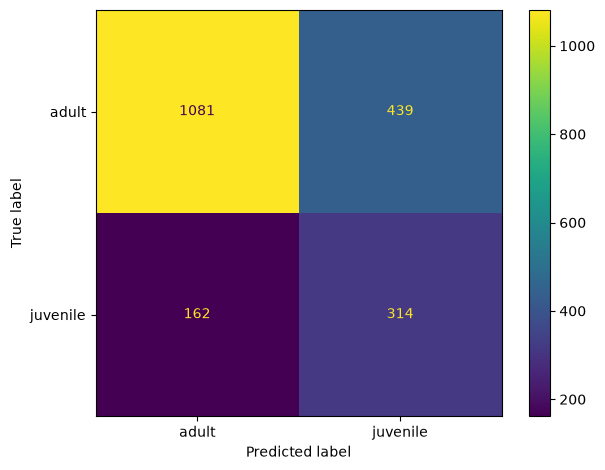

Classification Report:
              precision    recall  f1-score   support

       adult       0.87      0.71      0.78      1520
    juvenile       0.42      0.66      0.51       476

    accuracy                           0.70      1996
   macro avg       0.64      0.69      0.65      1996
weighted avg       0.76      0.70      0.72      1996



In [13]:
y_pred_tree = tree_best.predict(X_test)

print("Accuracy:")
print(accuracy_score(y_test, y_pred_tree))

print("Confusion Matrix:")
cm_tree = confusion_matrix(y_test, y_pred_tree)
print(cm_tree)
disp = ConfusionMatrixDisplay(cm_tree, display_labels=tree_best.classes_)
disp.plot()
plt.tight_layout()
plt.savefig("../reports/figures/tree_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred_tree))


Here, we can see that again, the model was better at predicting adults than juveniles. This tree, however, had a much higher recall for juveniles and a lower precision.

Again, the higher precision and recall of adult cases most likely comes from the amount of adult cases that this model was trained on.


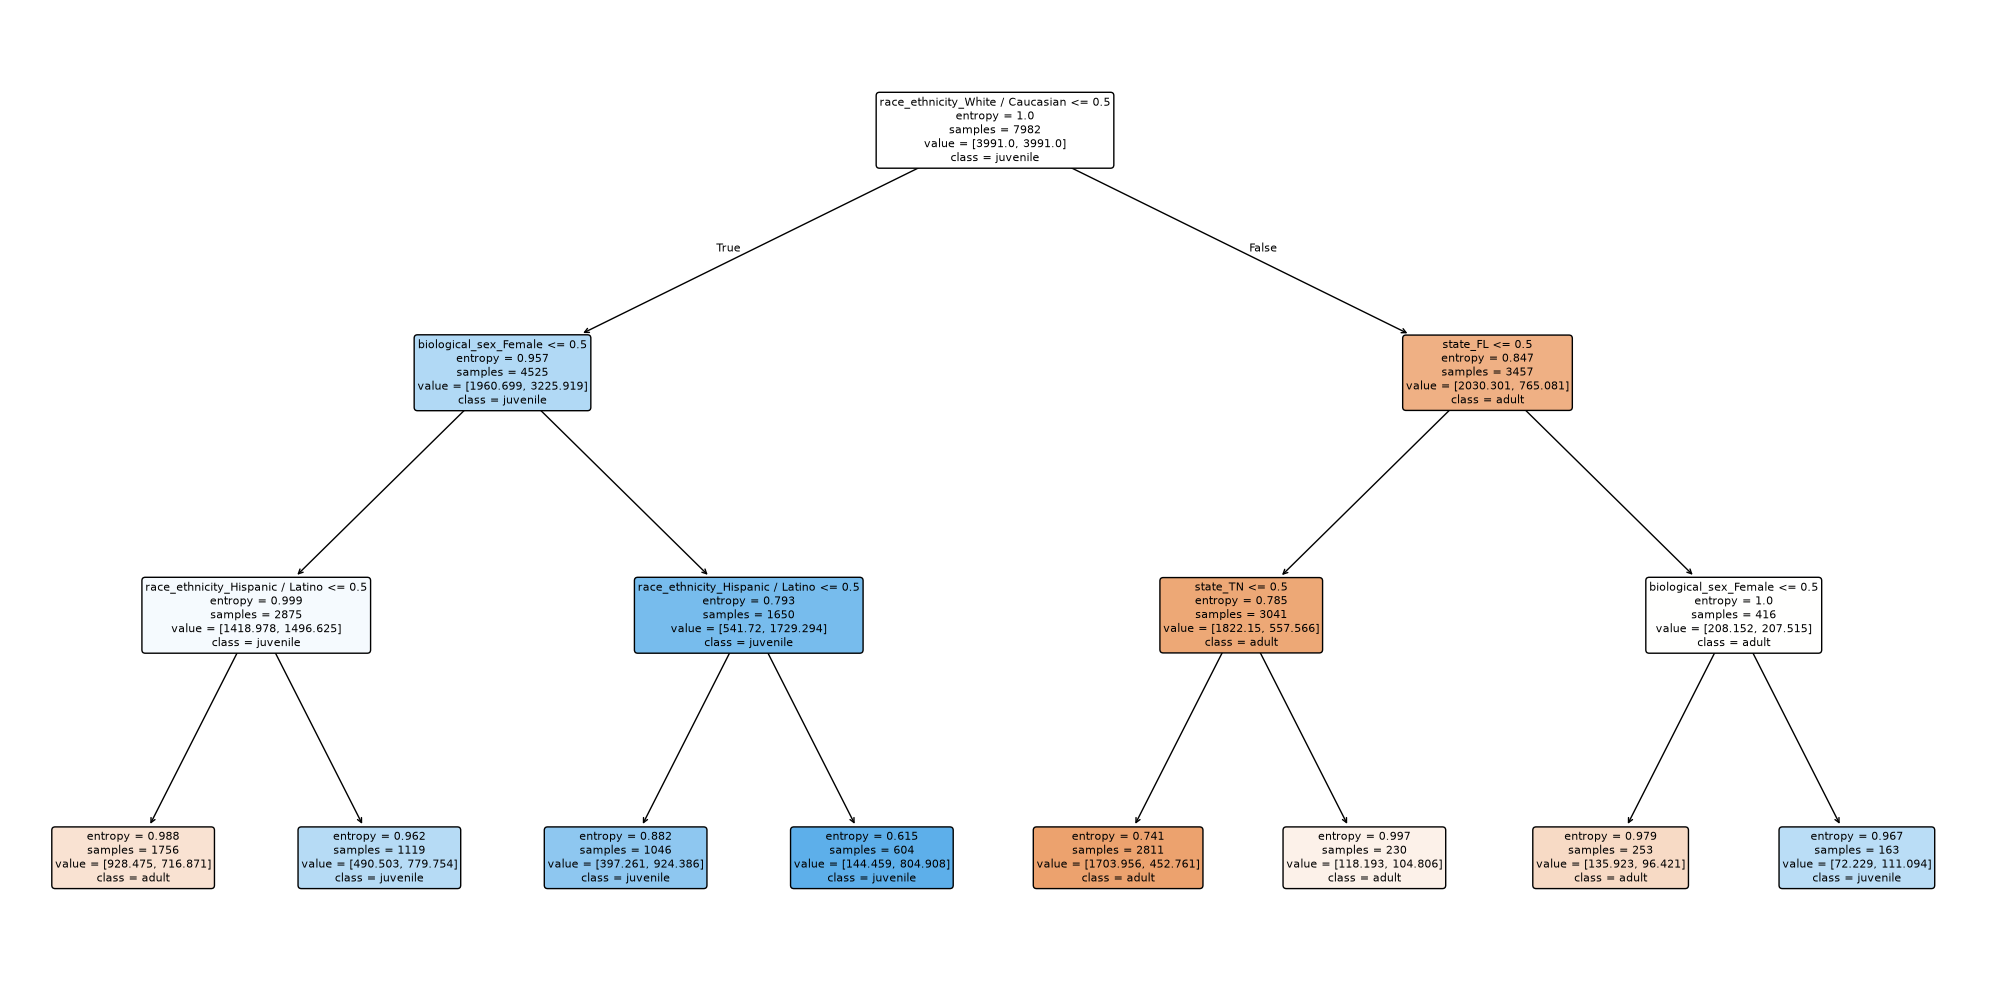

|--- race_ethnicity_White / Caucasian <= 0.50
|   |--- biological_sex_Female <= 0.50
|   |   |--- race_ethnicity_Hispanic / Latino <= 0.50
|   |   |   |--- class: adult
|   |   |--- race_ethnicity_Hispanic / Latino >  0.50
|   |   |   |--- class: juvenile
|   |--- biological_sex_Female >  0.50
|   |   |--- race_ethnicity_Hispanic / Latino <= 0.50
|   |   |   |--- class: juvenile
|   |   |--- race_ethnicity_Hispanic / Latino >  0.50
|   |   |   |--- class: juvenile
|--- race_ethnicity_White / Caucasian >  0.50
|   |--- state_FL <= 0.50
|   |   |--- state_TN <= 0.50
|   |   |   |--- class: adult
|   |   |--- state_TN >  0.50
|   |   |   |--- class: adult
|   |--- state_FL >  0.50
|   |   |--- biological_sex_Female <= 0.50
|   |   |   |--- class: adult
|   |   |--- biological_sex_Female >  0.50
|   |   |   |--- class: juvenile



In [14]:
# Plot the fitted tree (readable when max_depth is small, e.g. 3-5)
feature_names_tree = (
    tree_best.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .get_feature_names_out(cat_features)
)

plt.figure(figsize=(20, 10))
plot_tree(
    tree_best.named_steps["tree"],
    feature_names=feature_names_tree,
    class_names=tree_best.named_steps["tree"].classes_.astype(str),
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.tight_layout()
plt.savefig("../reports/figures/tree_plot.png", dpi=150, bbox_inches="tight")
plt.show()

# Optional text rules
print(export_text(tree_best.named_steps["tree"], feature_names=list(feature_names_tree)))


When making a decision tree, I always like to show the graph of it to give me a greater understanding of each leaf, the tree's depth, and the decisions it made.

Here we can see that the heaviest decision path to select juvenile was:
not white -> female -> hispanic/latino
Here we can see that the heaviest decision path to select adult was:
white -> not florida -> not Tennessee

We can see that the different features of our set really allowed the tree to learn what classified an adult and what classified a juvenile.


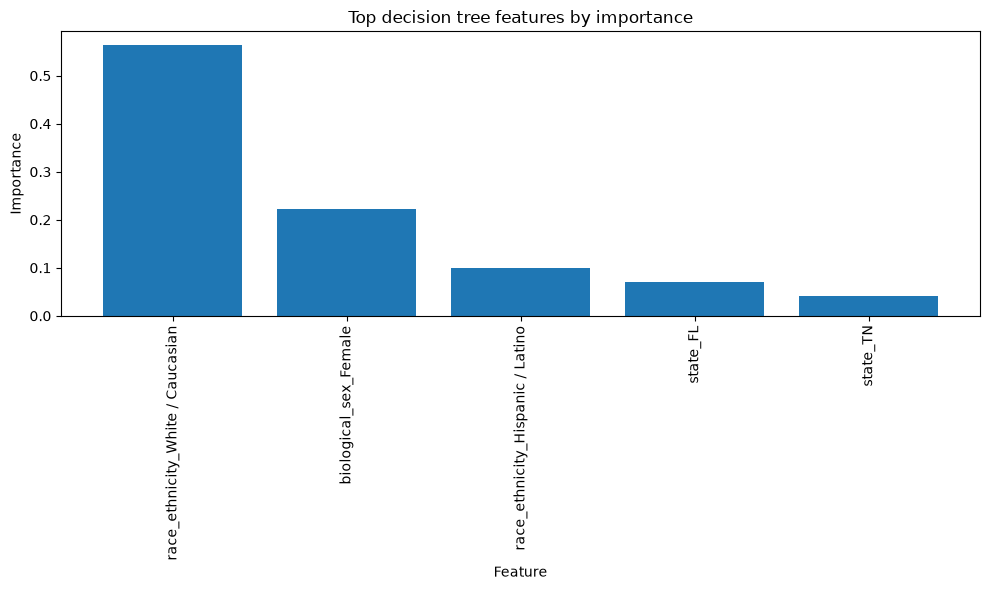

In [15]:
# Top features by tree impurity importance
importances = tree_best.named_steps["tree"].feature_importances_
top_n = 20
order = np.argsort(importances)[::-1][:top_n]
order = [i for i in order if importances[i] > 0][:top_n]

plt.figure(figsize=(10, 6))
plt.bar([feature_names_tree[i] for i in order], importances[order])
plt.xticks(rotation=90)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Top decision tree features by importance")
plt.tight_layout()
plt.savefig("../reports/figures/tree_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


This is a list of the top 5 most important features for the tree in its decision-making process.


## Model comparison


Majority class in training: adult
Baseline accuracy: 0.7615

                          accuracy  precision_adult  precision_juvenile  \
model                                                                     
baseline_always_majority     0.762            0.762               0.000   
logistic_regression          0.814            0.822               0.743   
decision_tree                0.699            0.870               0.417   

                          recall_adult  recall_juvenile  f1_adult  f1_juvenile  
model                                                                           
baseline_always_majority         1.000            0.000     0.865        0.000  
logistic_regression              0.964            0.334     0.887        0.461  
decision_tree                    0.711            0.660     0.782        0.511  


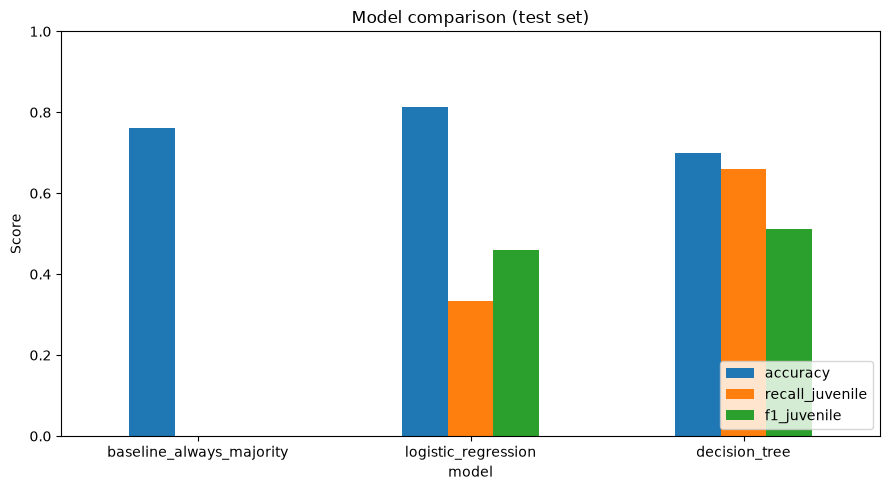

In [19]:
# Majority-class baseline: always predict the most common training label
baseline_label = y_train.value_counts().idxmax()
y_pred_baseline = np.full(shape=y_test.shape, fill_value=baseline_label)
baseline_acc = accuracy_score(y_test, y_pred_baseline)

# Align predictions with class order for precision/recall/f1
labels = list(logreg_best.classes_)

def class_metrics(y_true, y_hat, labels):
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_hat, labels=labels, zero_division=0
    )
    return {
        "accuracy": accuracy_score(y_true, y_hat),
        **{f"precision_{lab}": p for lab, p in zip(labels, prec)},
        **{f"recall_{lab}": r for lab, r in zip(labels, rec)},
        **{f"f1_{lab}": f for lab, f in zip(labels, f1)},
    }

y_pred_logreg = logreg_best.predict(X_test)
y_pred_tree = tree_best.predict(X_test)

comparison = pd.DataFrame(
    [
        {"model": "baseline_always_majority", **class_metrics(y_test, y_pred_baseline, labels)},
        {"model": "logistic_regression", **class_metrics(y_test, y_pred_logreg, labels)},
        {"model": "decision_tree", **class_metrics(y_test, y_pred_tree, labels)},
    ]
).set_index("model")

print(f"Majority class in training: {baseline_label}")
print(f"Baseline accuracy: {baseline_acc:.4f}")
print()
print(comparison.round(3))

# bar chart: accuracy + juvenile recall/F1
plot_cols = ["accuracy", "recall_juvenile", "f1_juvenile"]
ax = comparison[plot_cols].plot(kind="bar", figsize=(9, 5), rot=0)
ax.set_ylabel("Score")
ax.set_title("Model comparison (test set)")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../reports/figures/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


It's always nice to have a direct comparison section to see the strengths and weaknesses of each model.

Here, the first bar represents if you were to always select the majority class, which was adults.

For the 2 models, we also plotted recall and f1 for the juvenile class. F1 score is a score that balances the precision and recall of the model.

We can see that the logistic regression model did barely better than just predicting the majority class and the decision tree actually did worse.

It's clear to see that the logistic regression model's poor recall brought down its F1 score by a lot. 

Overall, I think that neither model was perfect for this set. 
The logistic regression model was very precise on both sets, but its overconfidence of adults made it miss many juvenile cases.
The decision tree model was moderately precise on both sets, but made up for it in catching more juvenile cases. 

If purely looking for separation of groups, the logistic regression model is the clear choice.
If looking for better feature classification and better recall, then the tree would be better.

Depending on what you are looking for in the data and what project you are working on, the models and rankings could change.


## Save models


In [17]:
# persist best pipelines for reuse outside the notebook
joblib.dump(logreg_best, "../models/logreg_age_group.joblib")
joblib.dump(tree_best, "../models/tree_age_group.joblib")
print("Saved:")
print("  ../models/logreg_age_group.joblib")
print("  ../models/tree_age_group.joblib")


Saved:
  ../models/logreg_age_group.joblib
  ../models/tree_age_group.joblib
